## **Modelo de previsão de preços de passagens aéreas**

## **Objetivo**

#### Esse projeto busca desenvolver um modelo de Machine Learning capaz de prever o preço de passagens aéreas com base nas características do voo, como companhia aérea, duração, número de paradas e origem/destino.

#### o estudo simula um cenário real de negócio, onde a previsão de preços pode auxiliar em estratégias de precificação, análise de mercado e tomada de decisão.

## **Bibliotecas**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import(
    train_test_split,
    cross_val_score,
    RandomizedSearchCV,
    KFold
)

from sklearn.metrics import(
    RocCurveDisplay,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay
)

from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from scipy.stats import randint, uniform

from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    RocCurveDisplay,
    r2_score
)

In [2]:
df = pd.read_excel('../base/Data_Train.xlsx')

df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


## **Base de dados**

**Variáveis e informações do dataset:**

'Airline' com o nome das 12 cia. aéres.

'Date_of_Journey', 'Source' e 'Destination' - trás as características, como data da viagem, origem e destino.

'Route', variável com os trajetos.

'Dep_Time', 'Arrival_Time' e 'Duration' com os horários do voo, de chegada e duração.

'Total_Stops' total de paradas.

'Additional_Info' trás informação do vôo, se está incluso refeição a bordo, ou bagagem despachada ou não, entre outras informações.

**Price** é a variável-alvo com preços das passagens.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [4]:
print('Número de linhas duplicadas:')
print(df.duplicated().sum())

Número de linhas duplicadas:
220


## **Análise das duplicatas**

In [5]:
df[df.duplicated(keep=False)].sort_values(by='Date_of_Journey', ascending=False).head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
4710,Jet Airways,9/06/2019,Delhi,Cochin,DEL → NAG → BOM → COK,14:35,12:35 10 Jun,22h,2 stops,No info,13376
6808,Jet Airways,9/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,09:40,04:25 10 Jun,18h 45m,2 stops,In-flight meal not included,10368
1312,Jet Airways,9/06/2019,Delhi,Cochin,DEL → NAG → BOM → COK,06:45,12:35 10 Jun,29h 50m,2 stops,No info,13376
1360,Jet Airways,9/06/2019,Delhi,Cochin,DEL → IDR → BOM → COK,05:30,04:25 10 Jun,22h 55m,2 stops,No info,13292
9191,Jet Airways,9/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,09:40,12:35 10 Jun,26h 55m,2 stops,In-flight meal not included,10368


#### As duplicatas representam cerca de 20% do dataset e não serão removidas, pois como não há variável de identificação,

#### é possível a mesma pessoa comprar mais de uma passagem com as mesmas informações de destino, rotas por exemplo,

#### portanto, o dataset permanecerá com todos os registros.

## **Tratamento de nulos**

#### Como há apenas um registro com valores nulos, essa linha será excluida da base por não causar impacto significativo.

In [6]:
df = df.dropna(subset=['Total_Stops'])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10682 non-null  object
 1   Date_of_Journey  10682 non-null  object
 2   Source           10682 non-null  object
 3   Destination      10682 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10682 non-null  object
 6   Arrival_Time     10682 non-null  object
 7   Duration         10682 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10682 non-null  object
 10  Price            10682 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 1001.4+ KB


## **Separação das bases**

#### é importante nessa etapa separar as bases para treinamento e as bases que serão usadas somente no final para validação.

In [7]:
X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7477 entries, 749 to 7270
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          7477 non-null   object
 1   Date_of_Journey  7477 non-null   object
 2   Source           7477 non-null   object
 3   Destination      7477 non-null   object
 4   Route            7477 non-null   object
 5   Dep_Time         7477 non-null   object
 6   Arrival_Time     7477 non-null   object
 7   Duration         7477 non-null   object
 8   Total_Stops      7477 non-null   object
 9   Additional_Info  7477 non-null   object
dtypes: object(10)
memory usage: 642.6+ KB


## **Recriando base + target de treino**

In [8]:
X_train['Price'] = y_train

X_train.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
749,Jet Airways,27/06/2019,Mumbai,Hyderabad,BOM → HYD,10:20,11:50,1h 30m,non-stop,No info,8040
6077,SpiceJet,21/06/2019,Kolkata,Banglore,CCU → BLR,17:10,19:40,2h 30m,non-stop,No info,3873
2373,Multiple carriers,27/05/2019,Delhi,Cochin,DEL → BOM → COK,15:00,01:30 28 May,10h 30m,1 stop,No info,13377
2442,Air Asia,9/05/2019,Kolkata,Banglore,CCU → DEL → BLR,22:40,10:40 10 May,12h,1 stop,No info,5192
5402,Air India,9/06/2019,Delhi,Cochin,DEL → AMD → BOM → COK,19:45,19:15 10 Jun,23h 30m,2 stops,No info,9968


## **Análise Exploratória dos dados (EDA)**

### **Entendendo a variável alvo**

In [9]:
X_train['Price'].describe()

count     7477.000000
mean      9110.983550
std       4651.400285
min       1759.000000
25%       5277.000000
50%       8372.000000
75%      12373.000000
max      79512.000000
Name: Price, dtype: float64

<Axes: ylabel='Price'>

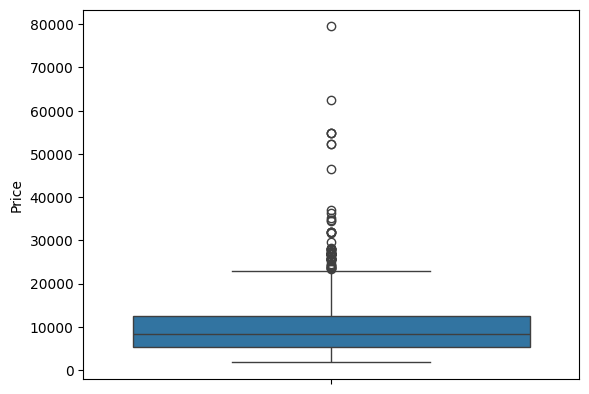

In [10]:
sns.boxplot(X_train['Price'])

#### A maior parte das passagens se concentram próximo de 10.000, com media de 9.121,50, indo até 40.000.

#### há pouquíssimos valores acima disso, e um único registro de valor extremo de 79.512, bem distante da distribuição média dos dados e será analisada nas etapas seguintes para tratamento.

### **Análise de passagens média por cia. aérea**

In [11]:
agrupamento = X_train.groupby('Airline')['Price'].mean().reset_index().sort_values(by='Price', ascending=False)

agrupamento.head()

,Airline,Price
5,Jet Airways Business,58588.600000
4,Jet Airways,11630.334077
7,Multiple carriers Premium economy,11431.333333
6,Multiple carriers,10956.413462
1,Air India,9773.115132


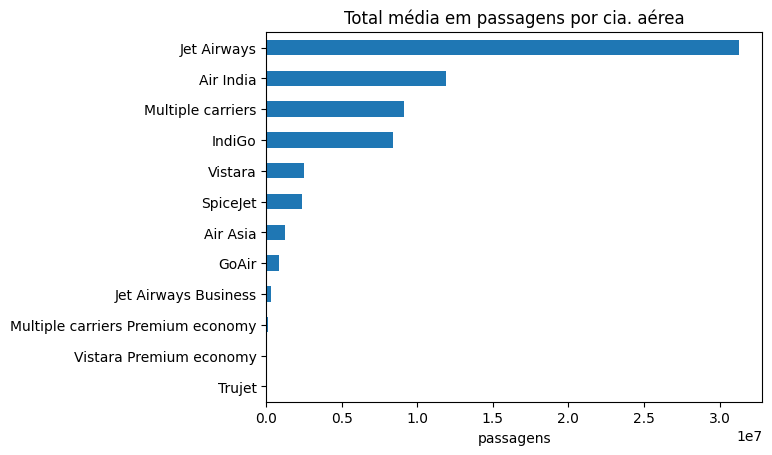

In [12]:
X_train.groupby('Airline')['Price'].sum().sort_values(ascending=True).plot(kind='barh')

plt.title('Total média em passagens por cia. aérea')
plt.xlabel('passagens')
plt.ylabel('')

plt.show()

#### a cia. 'Jet Airways' é a Airline número 1, com ~58.588 mil na média dos preços observados com passagens, bem disperso das outras companhias. Há uma diferença de, aproximadamente, 46.910 mil para a Airline número 2.

#### As top 5 linhas aéreas, além da 'Jet Airways, vem: 'Air India', 'Multiple carriers', 'IndiGo' e 'Vistara'

In [13]:
X_train.groupby('Airline')['Price'].count().reset_index().sort_values(by='Price', ascending=False).head()

,Airline,Price
4,Jet Airways,2688
3,IndiGo,1478
1,Air India,1216
6,Multiple carriers,832
8,SpiceJet,549


#### Analisando por volume, 'Jet Airways' permanece ganhando, mas em segundo lugar aparece 'IndiGo', que em faturamento fica em 4° lugar,

#### indicando que possivelmente possui passagens mais baratas, pois mesmo 'Air india' e 'Multiple carriers' tendo menos volume de viagens, ocupam o 2° e 3° lugar de faturamento, respectivamente.

### **Análise das origens e destinos**

In [14]:
or_dest = pd.crosstab(
    X_train['Source'],
    X_train['Destination']
)

or_dest

Destination,Banglore,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
Source,,,,,,
Banglore,0,0,891,0,0,671
Chennai,0,0,0,0,275,0
Delhi,0,3163,0,0,0,0
Kolkata,2008,0,0,0,0,0
Mumbai,0,0,0,469,0,0


#### As rotas mais frequentes são de Delhi para Cochin, com 3.156,

#### seguido de Kolkata para Banglore, com 2.026

## **Análise de paradas vs Preço**

<Axes: xlabel='Total_Stops', ylabel='Price'>

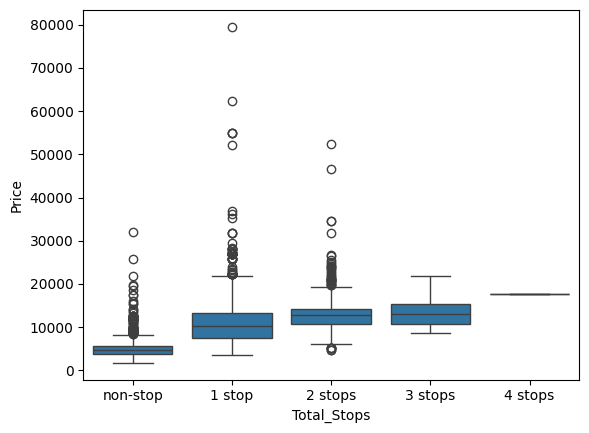

In [15]:
sns.boxplot(
    data=X_train,
    x='Total_Stops',
    y='Price'
)

#### vôos com 1 parada possuem os dados mais dispersos do dataset.

#### há um aumento gradativo dos preços médios, conforme mais paradas, indicando vôos com mais paradas, rotas mais complexas e preços maiores.

## **Feature Engineering**

In [16]:
# juntando as bases para aplicar as tranformações em toda a base
# removendo variável target
X_train = X_train.drop('Price', axis=1)

# juntando as bases para aplicar as tranformações em toda a base

X_full = pd.concat(
    [X_train, X_test]
)

X_full.shape

(10682, 10)

In [17]:
X_full.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
749,Jet Airways,27/06/2019,Mumbai,Hyderabad,BOM → HYD,10:20,11:50,1h 30m,non-stop,No info
6077,SpiceJet,21/06/2019,Kolkata,Banglore,CCU → BLR,17:10,19:40,2h 30m,non-stop,No info


### **Transformando data**

In [18]:
X_full['Date_of_Journey'] = pd.to_datetime(X_full['Date_of_Journey'], dayfirst=True)

X_full['journey_day'] = X_full['Date_of_Journey'].dt.day

X_full['journey_month'] = X_full['Date_of_Journey'].dt.month

X_full = X_full.drop('Date_of_Journey', axis=1)

### **Transformando horário**

In [19]:
X_full['dep_hour'] = pd.to_datetime(X_full['Dep_Time'], format='%H:%M').dt.hour

X_full['arrival_hour'] = pd.to_datetime(X_full['Arrival_Time'].str.split(' ').str[0], format='%H:%M').dt.hour

X_full = X_full.drop(['Dep_Time', 'Arrival_Time'], axis=1)

### **Transformando duração**

In [20]:
# garantindo que tudo é string
X_full['Duration'] = X_full['Duration'].astype(str)

# extraindo horas
X_full['duration_hours'] = X_full['Duration'].str.extract('(\d+)h').fillna(0).astype(int)

# extraindo minutos
X_full['duration_minutes'] = X_full['Duration'].str.extract('(\d+)m').fillna(0).astype(int)

# convertendo tudo para minutos
X_full['duration_total'] = X_full['duration_hours'] * 60 + X_full['duration_minutes']

# remover colunas intermediárias
X_full = X_full.drop(['Duration', 'duration_hours', 'duration_minutes'], axis=1)

### **Transformando paradas (Total_Stops)**

In [21]:
map = ({
    'non-stop': 0,
    '1 stop': 1,
    '2 stops': 2,
    '3 stops': 3,
    '4 stops': 4
})

X_full['Total_Stops'] = X_full['Total_Stops'].map(map).fillna(0).astype(int)

## **Remoção de variáveis**

#### 'Route' pois trás a mesma informação da variável 'Total_Stops'

#### e 'Additional_Info' tem pouco poder preditivo e muitos registros sem informação.

In [22]:
X_full = X_full.drop(columns=['Route', 'Additional_Info'])

## **Pré-processamento**

### **Transformação das colunas categóricas em numéricas**

In [23]:
X_full = pd.get_dummies(
    X_full,
    columns= ['Airline', 'Source', 'Destination'],
    drop_first=True
)

X_full.shape

(10682, 26)

## **Modelagem**

In [24]:
# separando bases novamente, agora com variáveis novas e limpas
X_train = X_full.iloc[:len(X_train)]
X_test = X_full.iloc[len(X_train):]

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

## **Treinamento baseline com cross validation**

In [25]:
model_base = DecisionTreeRegressor(
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# treinando
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    model_base,
    X_tr,
    y_tr,
    cv=cv,
    scoring='r2'
)

print(f"R² em cada fold: {scores}")
print(f"R² Médio: {scores.mean():.2f}")

R² em cada fold: [0.64694179 0.70486112 0.62800482 0.60759907 0.70936459]
R² Médio: 0.66


#### o modelo captura parte do padrão, mas ainda com espaço para melhorar.

#### o treinamento com cross validation apresentou um modelo baseline consistente em diferentes subamostras dos dados.

In [26]:
model_base.fit(X_tr, y_tr)

y_pred1 = model_base.predict(X_val)

r2_base = r2_score(y_val, y_pred1)
mae_base = mean_absolute_error(y_val, y_pred1)
rmse_base = np.sqrt(mean_squared_error(y_val, y_pred1))

print(f'R²: {r2_base:.2f}\n')
print(f'MAE: {mae_base:.1f}\n')
print(f'RMSE: {rmse_base:.1f}')

R²: 0.65

MAE: 1704.4

RMSE: 2674.5


#### o modelo explica aproximadamente 65% da variabilidade dos preços, 

#### o modelo está errando o preço da passagem em 1.704, representa erro de ~18% do valor

## **Análise de feature importances**

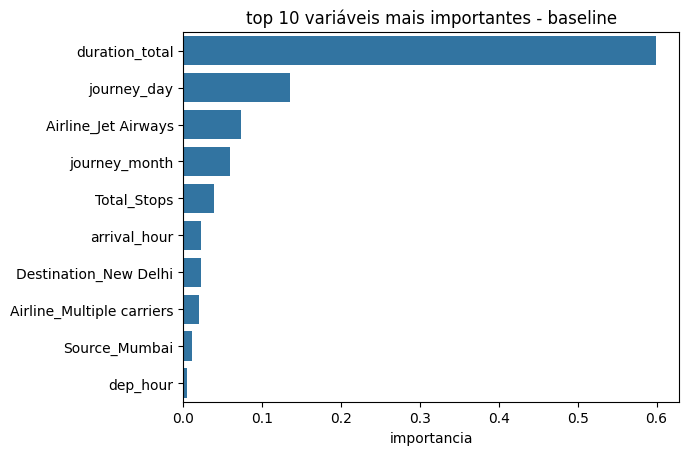

In [27]:
importancia = model_base.feature_importances_

feature_importances = pd.DataFrame({
    'variaveis': X_tr.columns,
    'importancia': importancia
}).sort_values(by='importancia', ascending=False).head(10)

sns.barplot(
    data=feature_importances,
    x='importancia',
    y='variaveis',
)

plt.title("top 10 variáveis mais importantes - baseline")
plt.ylabel('')

#plt.savefig('../imagens/importances_baseline.png')
plt.show()

#### o modelo baseou suas decisões principalmente pela variável duração total do vôo, indicando que viagens mais longas são mais complexas e de maior preço.

#### o dia do mês da viagem apresentou influência, podendo refletir padrões de demanda ao longo do período

#### seguido da cia. aérea 'Airline_Jet Airways', que apareceu em maior volume de vôos e maior média de preços, seguido de 'mês da viagem' e 'total de paradas'

#### o preço está sendo explicado principalmente por características operacionais do voo.

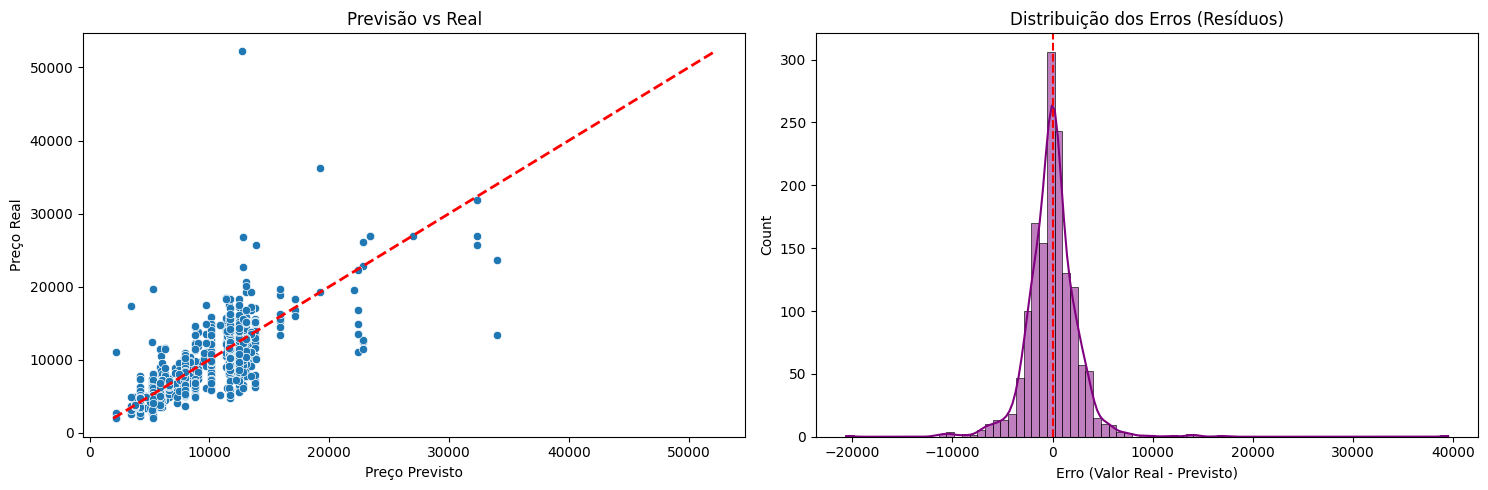

In [28]:
# 1. Calculando os resíduos (O que o modelo errou)
residuos = y_val - y_pred1

# 2. Criando o dashboard de análise
plt.figure(figsize=(15, 5))

# Gráfico A: Dispersão (Previsão vs Real)
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred1, y=y_val)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], '--r', lw=2) # Linha da perfeição
plt.title('Previsão vs Real')
plt.xlabel('Preço Previsto')
plt.ylabel('Preço Real')

# Gráfico B: Distribuição dos Resíduos
plt.subplot(1, 2, 2)
sns.histplot(residuos, kde=True, color='purple')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Distribuição dos Erros (Resíduos)')
plt.xlabel('Erro (Valor Real - Previsto)')

plt.tight_layout()

#plt.savefig('../imagens/residuos.png')
plt.show()

#### O gráfico de dispersão mostra que o modelo capturou a tendência central,

#### o modelo apresenta heterocedasticidade, com aumento da variância dos erros em valores mais altos de preço.

#### o histograma tem um sino centrado no zero, indica que a maioria dos erros são pequenos e os erros grandes são raros

#### nas próximas etapas, será testado um segundo modelo mais robusto que capture relações não-lineares mais complexas para ser analisada sua performance.

## **Treinamento e teste do 2° modelo**

In [29]:
model_xgb = XGBRegressor(
    n_estimators=200, 
    max_depth=5, 
    random_state=42,
)

# treinando com cross validation
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores_xgb = cross_val_score(
    model_xgb,
    X_tr,
    y_tr,
    cv=cv,
    scoring='r2'
)

print(f'Resultado em cada treino:\n{scores_xgb}')
print(f'R² médio:\n{scores_xgb.mean():.2f}')
print(f'desvio padrão:\n{scores_xgb.std():.4f}')

Resultado em cada treino:
[0.82101238 0.8144685  0.76143539 0.75937998 0.829647  ]
R² médio:
0.80
desvio padrão:
0.0304


In [30]:
# treinando
model_xgb.fit(X_tr, y_tr)

# teste
y_pred2 = model_xgb.predict(X_val)

print(f'R²: {r2_score(y_val, y_pred2):.2f}\n')
print(f'MAE: {mean_absolute_error(y_val, y_pred2):.1f}\n')
print(f'RMSE: {np.sqrt(mean_squared_error(y_val, y_pred2)):.1f}')

R²: 0.83

MAE: 1227.8

RMSE: 1883.5


#### o 2° modelo apresentou maior R², explicando aproximadamente 83% da variabilidade dos preços, 

#### e apresentou menor erro, errando o preço da passagem em ~1.228, representa erro de ~13% do valor,

#### nas próximas etapas será analisado se está ocorrendo um sobreajuste do modelo e sua capacidade de generalização para novos dados

## **Feature importances do XGboost**

In [31]:
importancia_xgb = model_xgb.feature_importances_

feature_importances = pd.DataFrame({
    'variaveis': X_tr.columns,
    'importancia': importancia_xgb
}).sort_values(by='importancia', ascending=False).head(3)

feature_importances

,variaveis,importancia
10,Airline_Jet Airways Business,0.491001
9,Airline_Jet Airways,0.104555
5,duration_total,0.064821


#### o modelo baseou suas decisões principalmente pela variável 'Airline_Jet Airways Business', porém como é uma variável rara, isso pode estar gerando overfitting e pouca generalização

#### o modelo será treinado sem essa feature para ser analisada sua performance.

## **Treinamento sem feature rara**

In [32]:
# removendo feature 
X_tr2 = X_tr.drop('Airline_Jet Airways Business', axis=1)
X_val2 = X_val.drop('Airline_Jet Airways Business', axis=1)

scores_xgb2 = cross_val_score(
    model_xgb,
    X_tr2,
    y_tr,
    cv=cv,
    scoring='r2'
)

print(f'Resultado em cada treino:\n{scores_xgb2}')
print(f'R² médio:\n{scores_xgb2.mean():.2f}')
print(f'desvio padrão:\n{scores_xgb2.std():.4f}')

Resultado em cada treino:
[0.75463581 0.8034355  0.68991119 0.75458181 0.79346931]
R² médio:
0.76
desvio padrão:
0.0399


In [33]:
# treinando
model_xgb.fit(X_tr2, y_tr)

# teste
y_pred3 = model_xgb.predict(X_val2)

r2_xgb = r2_score(y_val, y_pred3)
mae_xgb = mean_absolute_error(y_val, y_pred3)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred3))

print(f'R²: {r2_xgb:.2f}\n')
print(f'MAE: {mae_xgb:.1f}\n')
print(f'RMSE: {rmse_xgb:.1f}')

R²: 0.82

MAE: 1228.9

RMSE: 1907.5


#### o R² do test foi praticamente o mesmo, 0.83 (modelo com feature rara) e 0.82 (modelo sem feature rara), indicando overfitting local que não generalizava bem,

#### remover, portanto, simplifica o modelo, melhora robustez, evita dependencia de poucos dados e torna o modelo mais confiável.

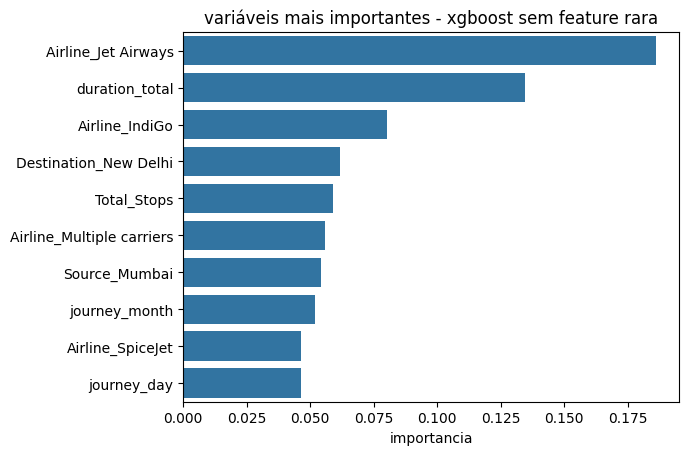

In [34]:
importancia_xgb2 = model_xgb.feature_importances_

feature_importances2 = pd.DataFrame({
    'variaveis': X_tr2.columns,
    'importancia': importancia_xgb2
}).sort_values(by='importancia', ascending=False).head(10)

sns.barplot(
    data=feature_importances2,
    x='importancia',
    y='variaveis',
)

plt.title("variáveis mais importantes - xgboost sem feature rara")
plt.ylabel('')

#plt.savefig('../imagens/importances_xgboost.png')
plt.show()

#### o modelo considera importante a variável 'Airline_Jet Airways', indicando que pelo nome da cia aérea, é possível estimar o preço,

#### 'Duration total' também faz sentido, pois voos mais longos gastam mais e cruzam distâncias maiores, sendo o variável numérica mais forte para precificação.

#### a variável 'Airline_IndiGo' também apresentou importância, indicando que pelo nome da cia aérea, é possível estimar o preço.

## **Seleção do modelo**

In [35]:
modelos = pd.DataFrame({
    'modelos': ['Árvore de decisão', 'Xgboost'],
    'métrica R²': [r2_base, r2_xgb],
    'métrica MAE': [mae_base, mae_xgb],
    'métrica RMSE': [rmse_base, rmse_xgb]
}).sort_values(by='métrica R²', ascending=False)

modelos

,modelos,métrica R²,métrica MAE,métrica RMSE
1,Xgboost,0.821078,1228.927368,1907.515400
0,Árvore de decisão,0.648265,1704.382555,2674.505007


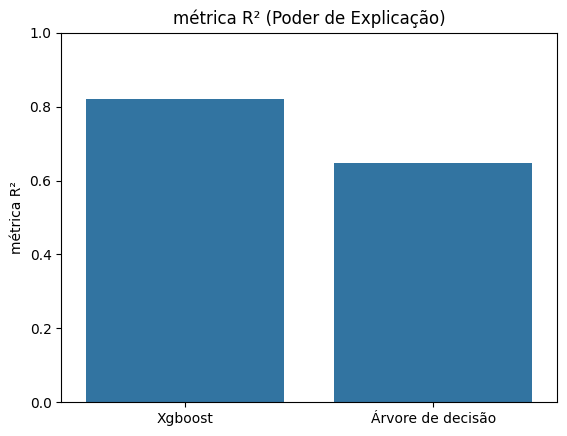

In [36]:
sns.barplot(
    data=modelos,
    x= 'modelos',
    y= 'métrica R²'
)

plt.ylim(0, 1)
plt.title('métrica R² (Poder de Explicação)')
plt.xlabel('')

#plt.savefig('../imagens/comparativo_modelos.png')

plt.show()

#### O modelo selecionado foi Xgboost, que apresentou melhor performance, aumentando o poder de explicação (R²) de 65% do modelo base para 82%,

#### aumento de 26% de R²

#### e reduzindo o erro médio de 1.704 para 1.228, apresentando redução de 28% do erro médio absoluto.

## **Ajustes de hiper parâmetros**

In [38]:
# instanciando o modelo
model_xgb_final = XGBRegressor(random_state = 42)

param_dist = {
    'n_estimators': randint(500, 1000),
    'learning_rate': uniform(0.01, 0.1),
    'max_depth': randint(8, 12),
    'colsample_bytree': uniform(0.7, 0.3),
    'subsample': uniform(0.7, 0.3),
    'min_child_weight': uniform(1, 9),
    'reg_lambda': uniform(0, 2),
    'reg_alpha': uniform(0, 2),
    'gamma': uniform(0, 1)
}

random_search = RandomizedSearchCV(
    estimator= model_xgb_final,
    param_distributions= param_dist,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    n_iter=150,
    random_state=42
)

random_search.fit(X_tr2, y_tr)

print(f'melhor R²: {random_search.best_score_:.2f}\n')
print(f'melhores parâmetros:\n {random_search.best_params_}')

melhor R²: 0.79

melhores parâmetros:
 {'colsample_bytree': np.float64(0.8778819804525109), 'gamma': np.float64(0.5800862078378112), 'learning_rate': np.float64(0.019148683739775487), 'max_depth': 8, 'min_child_weight': np.float64(4.520527894723418), 'n_estimators': 622, 'reg_alpha': np.float64(0.25902984256560835), 'reg_lambda': np.float64(1.7774961597379544), 'subsample': np.float64(0.986695449468926)}


#### R² médio dos 5 folds: 0.79,

#### Learning Rate e Estimators: o modelo dá pequenos passos (0.02) e usa um número razoável de árvores (622), além de profundidade (8) em cada árvore.

#### o modelo faz uma leve regularização: reg_alpha (0.25), gamma (0.6) e reg_lambda (1.77), tendo mais liberdade para explicar a variação dos preços.

#### colsample_bytree (0.87) e subsample (0.98), significa que o modelo está usando quase todos os dados e colunas em cada árvore.

## **Treinamento e teste final no dataset completo**

In [ ]:
# removendo variável rara
X_train = X_train.drop('Airline_Jet Airways Business', axis=1)

X_test = X_test.drop('Airline_Jet Airways Business', axis=1)

In [ ]:
# melhor modelo já treinado
best_model = random_search.best_estimator_

In [ ]:
# treino final
best_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,np.float64(0.8778819804525109)
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.dat

In [ ]:
y_pred_final = best_model.predict(X_test)

r2_final = r2_score(y_test, y_pred_final)
mae_final = mean_absolute_error(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))

print(f'R²: {r2_final:.2f}')
print(f'MAE: {mae_final:.1f}')
print(f'RMSE: {rmse_final:.1f}')

R²: 0.82
MAE: 1172.5
RMSE: 1907.5


#### O modelo permaneceu estável no teste com novos dados, com R² de 0.82, ele explica cerca de 82% a variabilidade dos preços.

#### o erro médio dos preços ficou em 1.172, houve uma melhoria e redução de quase 500 em comparação ao modelo baseline.

#### o RMSE de 1.907 mostra que o modelo ainda tem dificuldades em prever valores extremos, embora esse erro também tenha reduzido, indicando robustez do modelo

## **Explicabilidade do modelo**

### **Técnica feature importances**

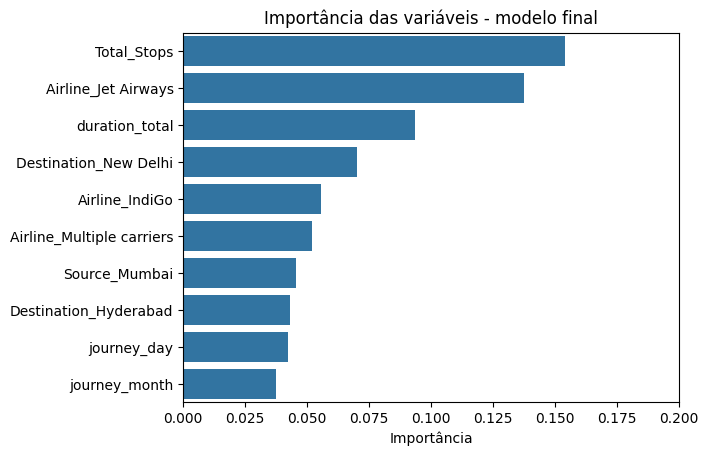

In [ ]:
importances = best_model.feature_importances_

tb_importancia = pd.DataFrame({
    'Variáveis': X_test.columns,
    'Importância': importances,
}).sort_values(by='Importância', ascending=False).head(10)

sns.barplot(
    data=tb_importancia,
    x='Importância',
    y='Variáveis'
)

plt.title('Importância das variáveis - modelo final')
plt.ylabel('')
plt.xlim(0, 0.2)

plt.savefig('../imagens/importances_final.png')

plt.show()

#### O modelo atribui maior importância a características operacionais do voo, como o número de paradas e a duração total, indicando que voos mais longos e complexos tendem a apresentar preços mais elevados.

#### Além disso, variáveis categóricas como companhia aérea também exercem influência relevante, sugerindo diferenças de precificação entre as empresas.

## **Explicabilidade dos erros e Considerações finais**

### **Gráfico de resíduos**

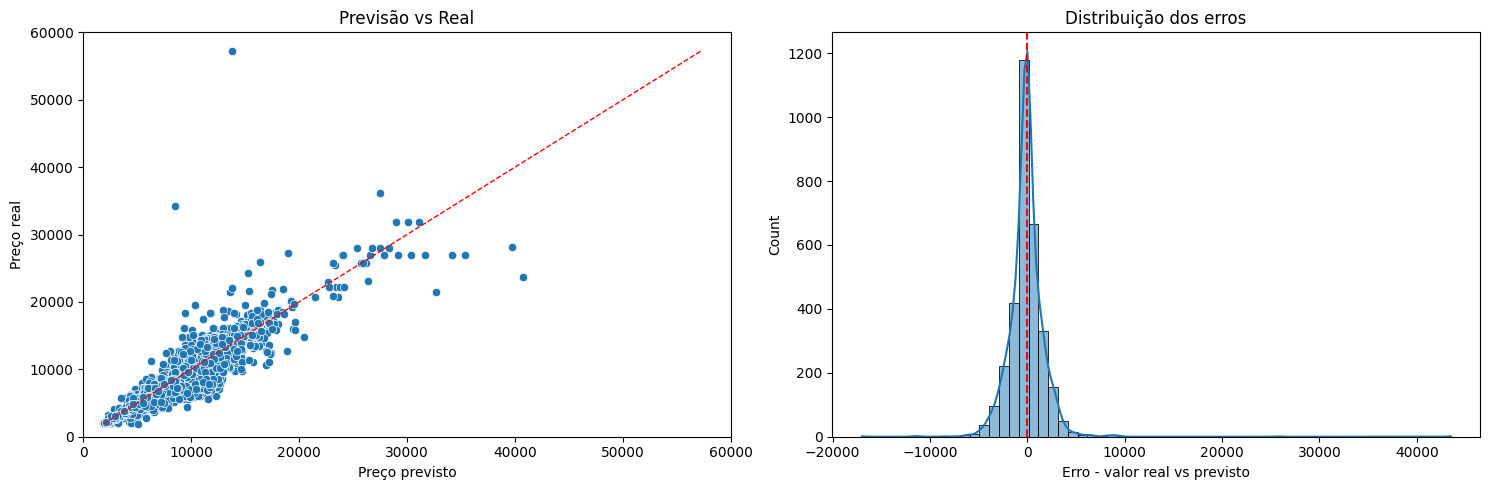

In [ ]:
residuos = y_test - y_pred_final


plt.figure(figsize=(15, 5))

plt.subplot(1,2,1)
sns.scatterplot(
    x=y_pred_final,
    y=y_test
)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=1) # Linha da perfeição
plt.xlim(0,60000.)
plt.ylim(0,60000.)

plt.title("Previsão vs Real")
plt.xlabel('Preço previsto')
plt.ylabel('Preço real')

plt.subplot(1,2,2)
sns.histplot(residuos, kde=True, bins=60)
plt.axvline(x=0, color='red', linestyle= '--')

plt.title('Distribuição dos erros')
plt.xlabel('Erro - valor real vs previsto')

plt.tight_layout()
plt.savefig('../imagens/residuos_final.png')
plt.show()

#### O gráfico de dispersão indica que o modelo conseguiu capturar a tendência central dos dados. No entanto, observa-se a presença de heterocedasticidade, com aumento da variância dos erros à medida que os preços se elevam, indicando maior dificuldade do modelo em prever passagens mais caras.

#### O histograma dos resíduos apresenta distribuição aproximadamente normal centrada em zero, o que sugere ausência de viés sistemático e que a maioria dos erros é de baixa magnitude, com poucos casos extremos.

#### Apesar do bom desempenho geral, o modelo ainda apresenta limitações na previsão de valores mais elevados, indicando oportunidade para melhorias futuras, seja por meio de novas variáveis explicativas ou modelos mais sofisticados.